<a href="https://colab.research.google.com/github/oliviabanerjee01-pop/Machine-Learning/blob/main/ML_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Starting value
w = 0

# Learning rate
alpha = 0.7


# Store our journey
history = []

for i in range(30):

    # Calculate cost
    cost = (w - 3)**2

    # Store w and cost
    history.append((w, cost))

    # Gradient
    gradient = 2 * (w - 3)

    # Gradient descent update
    w = w - alpha * gradient

print("Final w:", w)
print("Final cost:", (w - 3)**2)

Final w: 2.9999999999965414
Final cost: 1.1961684077039834e-23


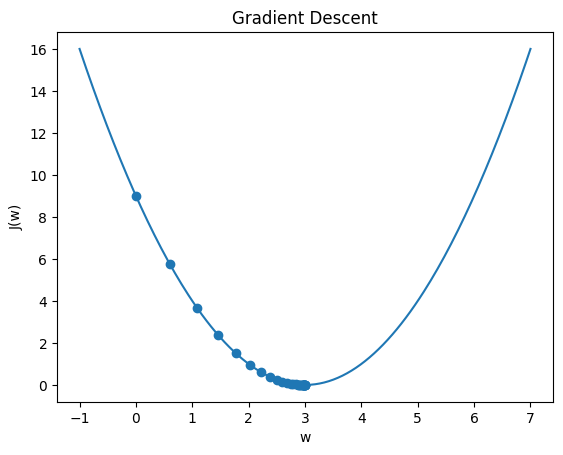

In [4]:
import numpy as np
import matplotlib.pyplot as plt

w = 0
alpha = 0.1

history = []

for i in range(30):

    cost = (w - 3)**2
    history.append((w, cost))

    gradient = 2 * (w - 3)

    w = w - alpha * gradient

# Convert history to arrays
history = np.array(history)

# Cost curve
w_values = np.linspace(-1, 7, 200)
cost_values = (w_values - 3)**2

plt.plot(w_values, cost_values)

# Gradient descent path
plt.scatter(history[:, 0], history[:, 1])

plt.xlabel("w")
plt.ylabel("J(w)")
plt.title("Gradient Descent")
plt.show()

w = 1.9737548787242036
b = 0.09475321533750963


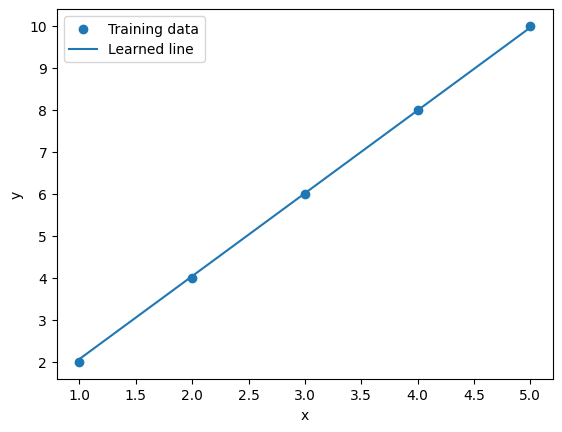

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Training data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initial parameters
w = 0
b = 0

# Learning rate
alpha = 0.01

# Number of iterations
iterations = 1000

for i in range(iterations):

    # Predictions
    predictions = w * x + b

    # Errors
    errors = predictions - y

    # Gradients
    dw = np.mean(errors * x)
    db = np.mean(errors)

    # Update parameters
    w = w - alpha * dw
    b = b - alpha * db

print("w =", w)
print("b =", b)
plt.scatter(x, y, label="Training data")

plt.plot(x, w * x + b, label="Learned line")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

w = 1.9737548787242036
b = 0.09475321533750963


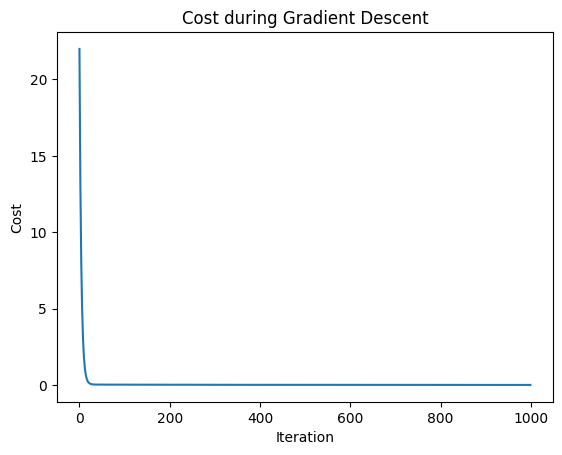

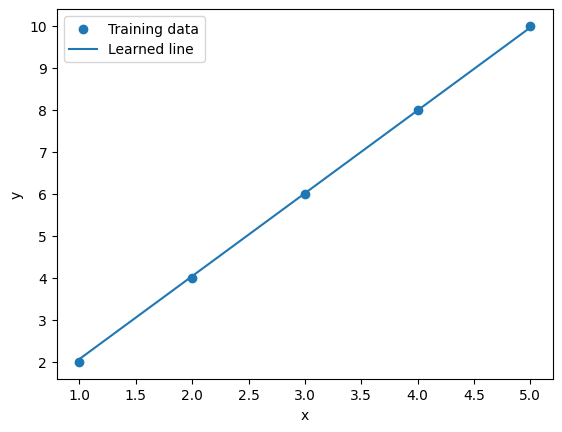

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Training data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Starting values for the model parameters
w = 0
b = 0

# Learning rate
alpha = 0.01

# Number of gradient descent steps
iterations = 1000

# Store cost after every iteration
cost_history = []

# Gradient descent
for i in range(iterations):

    # 1. Make predictions
    predictions = w * x + b

    # 2. Calculate prediction errors
    errors = predictions - y

    # 3. Calculate cost
    cost = np.mean(errors**2) / 2
    cost_history.append(cost)

    # 4. Calculate gradients
    dw = np.mean(errors * x)
    db = np.mean(errors)

    # 5. Update parameters
    w = w - alpha * dw
    b = b - alpha * db

# Show final parameters
print("w =", w)
print("b =", b)

# Plot cost history
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost during Gradient Descent")
plt.show()

# Plot training data and learned line
plt.scatter(x, y, label="Training data")
plt.plot(x, w * x + b, label="Learned line")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



---

# 1. Import NumPy and Matplotlib

```python
import numpy as np
import matplotlib.pyplot as plt
```

### `import numpy as np`

`numpy` is a Python library for numerical calculations.

Instead of manually doing:

```python
1 * 2
2 * 4
3 * 6
...
```

NumPy lets you work with entire arrays.

For example:

```python
x = np.array([1, 2, 3, 4, 5])
```

creates:

```text
[1 2 3 4 5]
```

The `as np` part simply gives NumPy a shorter nickname.

So:

```python
np.array()
```

means:

> "Use the `array()` function from NumPy."

---

### `import matplotlib.pyplot as plt`

Matplotlib is used to make graphs.

`pyplot` is the part we use for plotting.

`as plt` gives it a shorter name.

So:

```python
plt.plot(...)
```

means:

> "Use Matplotlib to make a plot."

---

# 2. Create the training data

```python
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
```

Think of this as our tiny dataset.

`x` is the **input**.

`y` is the **correct answer**.

So:

|  x |  y |
| -: | -: |
|  1 |  2 |
|  2 |  4 |
|  3 |  6 |
|  4 |  8 |
|  5 | 10 |

We're basically telling the computer:

> When `x = 1`, the answer is `2`.

> When `x = 2`, the answer is `4`.

etc.

There is an obvious relationship:

[
y=2x
]

But here's the important part:

**we aren't going to tell the computer that.**

We're going to make gradient descent discover it.

---

# 3. Initialize `w`

```python
w = 0
```

Remember the model:

[
f_{w,b}(x)=wx+b
]

`w` is the **weight**.

For a simple linear regression, it's basically the slope of the line.

We're starting with:

[
w=0
]

So initially:

[
f(x)=0x+b
]

The computer knows basically nothing yet.

---

# 4. Initialize `b`

```python
b = 0
```

`b` is the **bias**.

It's the intercept of the line.

Our initial model is therefore:

[
f(x)=0x+0
]

or simply:

[
f(x)=0
]

So initially the model predicts:

```text
x = 1 → prediction = 0
x = 2 → prediction = 0
x = 3 → prediction = 0
x = 4 → prediction = 0
x = 5 → prediction = 0
```

Our model is spectacularly bad. Fortunately, that's intentional.

---

# 5. Learning rate

```python
alpha = 0.01
```

`alpha` is the **learning rate**.

It controls how large each adjustment is.

Imagine you're standing on a hill and trying to reach the bottom.

A tiny learning rate:

```text
small step → small step → small step
```

is slow.

A huge learning rate:

```text
GIANT STEP → overshoot → GIANT STEP → chaos
```

can completely miss the minimum.

So:

```python
alpha = 0.01
```

means:

> Make relatively small adjustments.

---

# 6. Number of iterations

```python
iterations = 1000
```

An **iteration** means one round of:

```text
make predictions
→ calculate error
→ calculate gradient
→ update w and b
```

We're telling the computer:

> Do this process 1000 times.

You can experiment with:

```python
iterations = 10
```

or:

```python
iterations = 100
```

or:

```python
iterations = 5000
```

---

# 7. Start the gradient descent loop

```python
for i in range(iterations):
```

This means:

> Repeat the following code 1000 times.

`range(1000)` produces numbers from:

```text
0
1
2
3
...
999
```

`i` represents the current iteration.

We don't actually need `i` for the mathematics here. We just need the loop to repeat.

---

# 8. Make predictions

```python
predictions = w * x + b
```

This is the model:

[
f_{w,b}(x)=wx+b
]

Suppose we're currently at:

```python
w = 0
b = 0
```

Then:

```python
predictions = 0 * x + 0
```

Since `x` is:

```text
[1, 2, 3, 4, 5]
```

we get:

```text
[0, 0, 0, 0, 0]
```

Later, suppose gradient descent has reached:

```python
w = 1.8
b = 0.2
```

Then:

```text
prediction for x=1:
1.8(1) + 0.2 = 2

prediction for x=2:
1.8(2) + 0.2 = 3.8
```

And NumPy performs this for the entire array automatically.

---

# 9. Calculate the errors

```python
errors = predictions - y
```

We compare:

```text
prediction - actual answer
```

Initially:

```text
predictions = [0, 0, 0, 0, 0]

y           = [2, 4, 6, 8, 10]
```

Therefore:

```text
errors = [-2, -4, -6, -8, -10]
```

Negative means:

> The model predicted too low.

If the model predicted 7 when the actual answer was 5:

```text
7 - 5 = +2
```

Positive means:

> The model predicted too high.

---

# 10. Calculate the cost

```python
cost = np.mean(errors**2) / 2
```

This is Andrew Ng's cost function for linear regression:

[
J(w,b)=\frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2
]

Let's dismantle the Python.

### `errors**2`

`**` means exponentiation.

So:

```python
errors**2
```

means:

> Square every error.

For:

```text
[-2, -4, -6]
```

we get:

```text
[4, 16, 36]
```

Why square them?

Because otherwise positive and negative errors could cancel each other.

For example:

```text
+5 + (-5) = 0
```

That would falsely suggest zero error.

Squaring fixes that.

---

### `np.mean(...)`

`mean` calculates the average.

If we have:

```text
[4, 16, 36]
```

then:

[
\frac{4+16+36}{3}=18.67
]

---

### `/ 2`

Andrew Ng defines the cost function with the `1/2` factor:

[
J=\frac{1}{2m}\sum error^2
]

The `1/2` makes the derivative cleaner.

It doesn't fundamentally change where the minimum occurs.

---

# 11. Calculate the gradient with respect to `w`

```python
dw = np.mean(errors * x)
```

This is one of the most important lines.

The gradient tells us:

> **Which direction should `w` move to reduce the cost?**

For linear regression:

[
\frac{\partial J}{\partial w}
=============================

\frac{1}{m}
\sum
(f_{w,b}(x)-y)x
]

Our code:

```python
np.mean(errors * x)
```

is implementing that formula.

---

### Why multiply by `x`?

Because changing `w` affects the prediction according to:

[
wx
]

If `x` is large, changing `w` has a larger effect on the prediction.

So the gradient needs the `x` factor.

---

# 12. Calculate the gradient with respect to `b`

```python
db = np.mean(errors)
```

This calculates:

[
\frac{\partial J}{\partial b}
=============================

\frac{1}{m}\sum(f_{w,b}(x)-y)
]

Notice there is **no `x`**.

That's because `b` affects every prediction directly by the same amount:

[
f(x)=wx+b
]

Changing `b` by 1 changes every prediction by 1.

---

# 13. Update `w`

```python
w = w - alpha * dw
```

This is the actual **gradient descent step**.

The formula is:

[
w := w-\alpha\frac{\partial J}{\partial w}
]

Break it apart:

```text
w
```

Current value.

```text
dw
```

Direction/slope of the cost.

```text
alpha
```

How big a step to take.

So:

```python
alpha * dw
```

means:

> How much should I change `w`?

And:

```python
w - alpha * dw
```

means:

> Move `w` in the direction that decreases the cost.

---

# 14. Update `b`

```python
b = b - alpha * db
```

Exactly the same idea.

We're adjusting the bias in the direction that reduces the cost.

So every iteration does:

```text
Current w,b
     ↓
Make predictions
     ↓
Calculate errors
     ↓
Calculate gradients
     ↓
Change w,b
     ↓
Repeat
```

---

# 15. The complete algorithm

Putting it together:

```python
for i in range(iterations):

    predictions = w * x + b

    errors = predictions - y

    dw = np.mean(errors * x)
    db = np.mean(errors)

    w = w - alpha * dw
    b = b - alpha * db
```

That's **gradient descent for linear regression**.

The computer repeatedly asks:

> "Are my predictions wrong?"

Then:

> "Which direction should I change `w` and `b`?"

Then:

> "Take a small step that way."

Then repeat.

---

# 16. What happens over time?

Initially:

```text
w = 0
b = 0
```

Model:

[
y=0
]

Terrible.

After some iterations:

```text
w ≈ 0.8
b ≈ 0.5
```

Better.

Then:

```text
w ≈ 1.5
b ≈ 0.3
```

Better.

Then:

```text
w ≈ 1.9
b ≈ 0.1
```

Very good.

Eventually:

```text
w ≈ 2
b ≈ 0
```

And we've found approximately:

[
y=2x
]

without explicitly giving the model that answer.

---

# 17. Tracking the cost

Now we add:

```python
cost_history = []
```

This creates an empty Python list.

We'll put the cost from every iteration into it.

Then inside the loop:

```python
cost = np.mean(errors**2) / 2
cost_history.append(cost)
```

`append()` means:

> Add this value to the end of the list.

So eventually:

```text
cost_history =
[
  110,
  92,
  76,
  61,
  48,
  ...
  0.03,
  0.01
]
```

---

# 18. Plot the cost

```python
plt.plot(cost_history)
```

This tells Matplotlib:

> Put the iteration number on the x-axis and the cost values on the y-axis.

You'll get something roughly like:

```text
Cost
 ↑
 │\
 │ \
 │  \
 │   \
 │    \
 │     \______
 │            \____
 └──────────────────→ iterations
```

That downward curve is literally showing:

**gradient descent learning.**

The cost decreases as the parameters become better.

---

# 19. Plot the final learned line

After training:

```python
plt.scatter(x, y)
```

plots your actual training points.

Then:

```python
plt.plot(x, w * x + b)
```

plots the line your model learned.

So:

```python
plt.scatter(x, y, label="Training data")
plt.plot(x, w * x + b, label="Learned line")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
```

### `plt.scatter()`

Shows individual data points.

### `plt.plot()`

Draws your predicted line.

### `xlabel()`

Labels the horizontal axis.

### `ylabel()`

Labels the vertical axis.

### `legend()`

Shows what each thing represents.

### `show()`

Actually displays the graph.

---

# The entire code, annotated

```python
import numpy as np
import matplotlib.pyplot as plt

# Training data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Starting values for the model parameters
w = 0
b = 0

# Learning rate
alpha = 0.01

# Number of gradient descent steps
iterations = 1000

# Store cost after every iteration
cost_history = []

# Gradient descent
for i in range(iterations):

    # 1. Make predictions
    predictions = w * x + b

    # 2. Calculate prediction errors
    errors = predictions - y

    # 3. Calculate cost
    cost = np.mean(errors**2) / 2
    cost_history.append(cost)

    # 4. Calculate gradients
    dw = np.mean(errors * x)
    db = np.mean(errors)

    # 5. Update parameters
    w = w - alpha * dw
    b = b - alpha * db

# Show final parameters
print("w =", w)
print("b =", b)

# Plot cost history
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost during Gradient Descent")
plt.show()

# Plot training data and learned line
plt.scatter(x, y, label="Training data")
plt.plot(x, w * x + b, label="Learned line")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
```

## The 6 lines you should understand above everything else

If you remember the conceptual structure, you're golden:

```python
predictions = w * x + b
```

**What does my current model predict?**

```python
errors = predictions - y
```

**How wrong am I?**

```python
cost = np.mean(errors**2) / 2
```

**How bad is the model overall?**

```python
dw = np.mean(errors * x)
```

**Which way should `w` move?**

```python
db = np.mean(errors)
```

**Which way should `b` move?**

```python
w = w - alpha * dw
b = b - alpha * db
```

**Move them toward lower cost.**


